## EDA

loading the dataset

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# specifying the paths using os.path because absolute paths cannot be the same in every device
notebook_dir = os.path.abspath("")
parent_dir = os.path.abspath("..")
org_dataset_path = os.path.join(parent_dir, "datasets", "superstore_sales.csv")

df = pd.read_csv(org_dataset_path)
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-138688,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,US-2015-108966,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


looking for total rowcounts of each column, missing values and their datatypes

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       5009 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

number of missing values in each column

In [75]:
df.isna().sum()

Row ID              0
Order ID         4985
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code         0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
dtype: int64

dropping the rows with duplicate 'Order IDs' AND missnig values

In [76]:
df = df.drop_duplicates(['Order ID'])
df = df.dropna(subset=['Order ID'])

rechecking the brief info again

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5009 entries, 0 to 5008
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         5009 non-null   int64  
 1   Order ID       5009 non-null   str    
 2   Order Date     5009 non-null   str    
 3   Ship Date      5009 non-null   str    
 4   Ship Mode      5009 non-null   str    
 5   Customer ID    5009 non-null   str    
 6   Customer Name  5009 non-null   str    
 7   Segment        5009 non-null   str    
 8   Country        5009 non-null   str    
 9   City           5009 non-null   str    
 10  State          5009 non-null   str    
 11  Postal Code    5009 non-null   int64  
 12  Region         5009 non-null   str    
 13  Product ID     5009 non-null   str    
 14  Category       5009 non-null   str    
 15  Sub-Category   5009 non-null   str    
 16  Product Name   5009 non-null   str    
 17  Sales          5009 non-null   float64
 18  Quantity       5009

### looking for outliers in numerical data

In [78]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()


# this table clearly shows that where 75% of the sales lie under 210, max is above 22000 this indicates there might be possible outliers
# the profit also seems highly skewed because of the minimum count being almost -3840, also the max is above 5040 where 75% of the data is under 29
# these outliers can highly skew the averages and further analysis.

,Sales,Quantity,Discount,Profit
count,5009.000000,5009.000000,5009.000000,5009.000000
mean,228.361315,3.793172,0.156824,25.923857
std,630.511364,2.239179,0.206888,209.155535
min,0.444000,1.000000,0.000000,-3839.990400
25%,16.560000,2.000000,0.000000,1.764000
50%,52.272000,3.000000,0.200000,8.639100
75%,210.980000,5.000000,0.200000,28.792800
max,22638.480000,14.000000,0.800000,5039.985600


#### Scatter Plots to see the position and amount of outliers

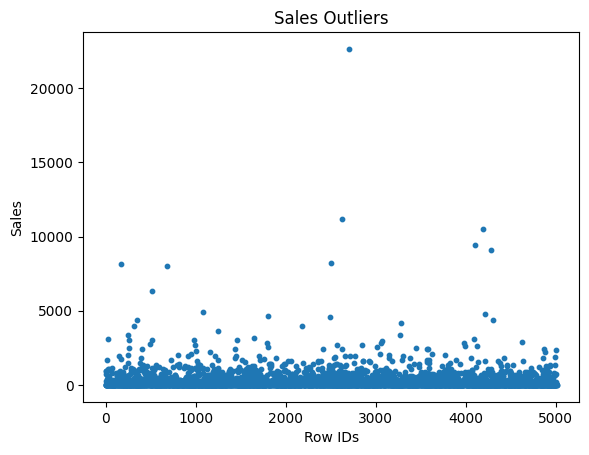

In [79]:
# Sales Column

plt.scatter(x=df['Row ID'], y=df['Sales'], s=10)

plt.xlabel("Row IDs")
plt.ylabel("Sales")
plt.title("Sales Outliers")

plt.show()

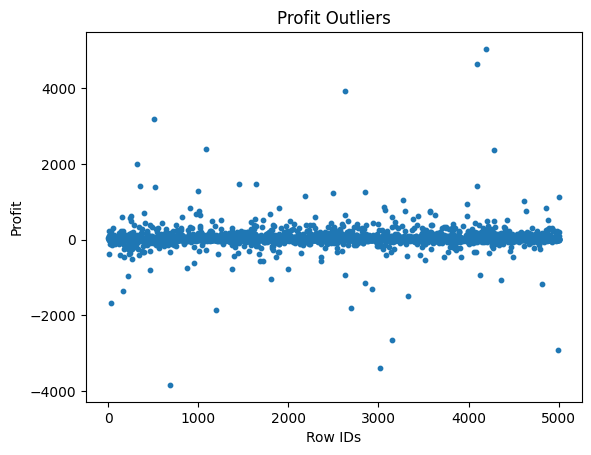

In [80]:
# Profit Column

plt.scatter(x=df['Row ID'], y=df['Profit'], s=10)

plt.xlabel("Row IDs")
plt.ylabel("Profit")
plt.title("Profit Outliers")

plt.show()

#### Dropping all the rows that contain outliers from profit and sales columns
 (sales over 5000 and profit below -100 and above 2000 be removed)

In [81]:
df = df[df['Sales'] <= 5000]
df = df[df['Profit'].between(-100, 2000)]

final col counts

In [82]:
df.info()

<class 'pandas.DataFrame'>
Index: 4842 entries, 0 to 5008
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         4842 non-null   int64  
 1   Order ID       4842 non-null   str    
 2   Order Date     4842 non-null   str    
 3   Ship Date      4842 non-null   str    
 4   Ship Mode      4842 non-null   str    
 5   Customer ID    4842 non-null   str    
 6   Customer Name  4842 non-null   str    
 7   Segment        4842 non-null   str    
 8   Country        4842 non-null   str    
 9   City           4842 non-null   str    
 10  State          4842 non-null   str    
 11  Postal Code    4842 non-null   int64  
 12  Region         4842 non-null   str    
 13  Product ID     4842 non-null   str    
 14  Category       4842 non-null   str    
 15  Sub-Category   4842 non-null   str    
 16  Product Name   4842 non-null   str    
 17  Sales          4842 non-null   float64
 18  Quantity       4842 non-

Exporting the raw dataset to csv

In [ ]:
# in sql, this raw dataset would be divided into separate tables

notebook_dir = os.path.abspath("")
parent_dir = os.path.abspath("..")
dataset_path = os.path.join(parent_dir, "datasets", "raw_dataset.csv")

df.to_csv(dataset_path, index=False)